## 6.1 TD法



**モンテカルロ法の欠点**: エピソードの終わりまでたどり着かないと、価値関数の更新ができない　→　連続タスクでは不可、時間を要する

**TD法**: モンテカルロ法と動的計画法を合わせたような手法


#### MC法による価値関数の推定

モンテカルロ法では期待値を集めたデータを平均することで求める。平均には標本平均と、前回MC法で用いた、指数移動平均があるが、今回は指数移動平均を考える。

指数移動平均...固定値α で平均を更新することで、新しいデータほど影響が大きく、古いデータほど影響が小さくなる方法。


$ \hspace{10mm} \displaystyle V'_\pi(S_t) = V_\pi(S_t) + \alpha (G_t - V_\pi(S_t)) \hspace{10mm} (6.5) $

この式は、価値関数$ V_\pi $ を$ G_t $ のほうへと更新している。どのくらい$ G_t $ のほうへ更新するかをα で調整する。

#### DP法による価値関数の推定

DP法はベルマン方程式に基づいて価値関数を逐次更新する。更新式は以下のようである。

$ \displaystyle \hspace{10mm} V'(s) = \sum_{a, s'} \pi(a|s) p(s'|s,a) \{r(s,a,s')+\gamma V(s')\} \hspace{15mm} (6.7)$

この式で重要な点は、「今の状態における価値関数」を「次の状態における価値関数」で更新している点(ブートストラップ)

#### DP法とMC法の価値関数の推定の違い

DP法 ... ブートストラップにより価値関数を推定する

MC法 ... 実際に得られた経験によって価値関数を更新

<img src="img/fig6_1.jpg" width=600>

TD法は下図のように次の行動と価値関数だけを用いて現在の価値関数を更新する。

$ \hspace{10mm} \displaystyle V'_\pi(S_t) = V'_\pi(S_t) + \alpha (R_t + \gamma V_\pi(S_{t+1}) - V_\pi(S_t)) \hspace{10mm} (6.9) $

<img src="img/fig6_2.jpg" width=600>

**TD法の利点**: MC法と比べてデータのばらつきが小さい(分散が小さい)

TD法は「推定値で推定値を更新している」(=ブートストラッピング)

TDターゲットは推定値が含まれるため**バイアス**が生じる

一方、MCターゲットには推定値が含まれないため、**バイアス**が生じない

<img src="img/fig6_4.jpg" width=600>

---

### 6.1.2. TD法の実装

TD法を用いた方策評価を実装する。

In [4]:
from collections import defaultdict
import numpy as np
from common.gridworld import GridWorld

In [26]:
# TD法の実装

class TdAgent:
    def __init__(self):
        # 更新率α, 割引率γ, 行動の選択肢の数
        self.alpha = 0.01
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        # 方策pi, 状態価値関数Vの初期化
        self.pi = defaultdict(lambda: random_actions)   # 方策はランダム、辞書型{0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        # 方策に従って行動を選択
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)


############# 新しい部分　#########################################
    
    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]   # ゴールの価値関数は0

        # 更新したい値
        target = reward + self.gamma * next_V

        # α倍だけ更新
        self.V[state] += self.alpha * (target - self.V[state])

###################################################################

以下がランダムな方策で行動して1000回のエピソードを得る。
そのエピソード中のデータs, a, r, s'を用いてTD法により状態価値関数Vを更新するプログラムである。

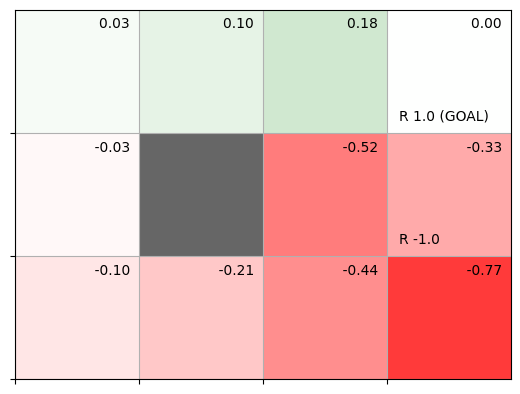

In [28]:
env = GridWorld()
agent = TdAgent()

episodes = 1000
for episodes in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

上のようにランダムな方策を持つエージェントの状態価値関数を推定できた。

---

## 6.2. SARSA

### 6.3. 方策オンのSARSA

方策評価の方法はわかったので、次は方策制御(改善)を行う。

SARSAは「方策オン」と「方策オフ」の二つがある。

まずは、「方策オン」の方を扱う。

最初に、TD法を状態価値関数V ではなく、行動価値関数Q について求める。行動価値関数を求めることで`argmax`を用いるだけで方策制御が可能

$ \hspace{10mm} \displaystyle Q'_\pi(S_t, A_t) = Q'_\pi(S_t, A_t) + \alpha (R_t + \gamma Q_\pi(S_{t+1}, A_{t+1}) - Q_\pi(S_t, A_t)) \hspace{10mm} (6.9) $


この場合、価値関数の更新に新たにt+1 での行動$A_{t+1} $ が必要になる。

<img src="img/fig6_6.jpg" width=600>

In [ ]:
from collections import defaultdict, deque
import numpy as np
from common.utils import greedy_probs
from common.gridworld import GridWorld

In [ ]:
# SARSAのエージェント実装

class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)       # 1. 'deque'を使う

    def get_action(self, state):
        action_probs = self.pi[state]       # 2. piから選ぶ
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return
        # 次の状態がゴールかどうかは一つ目のdoneでわかる
        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        # 3. 次のＱ関数、もし次の状態がゴールなら0とする。
        next_q = 0 if done else self.Q[(next_state, next_action)]

        # 4. TD法による更新
        target = reward + self.gamma * next_q
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        # 5. 方策の改善
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


**1. `deque`を使う**

ここではPython標準ライブラリの`collections.deque`を使う。これは指定された最大要素`maxlen`を超える要素が追加された場合には最も古い要素が削除される

**2. 方策を取り出す**

方策オン型であるので方策を一つしか持ちえない。よって、self.piから状態に応じた行動が選択される。

**3. ゴールの先は何もないので0**

**4. SARSAの式によってQ を更新する**

**5. `ε-greedy`法を用いた方策改善**

---

6.2.2. SARSAを動作させる

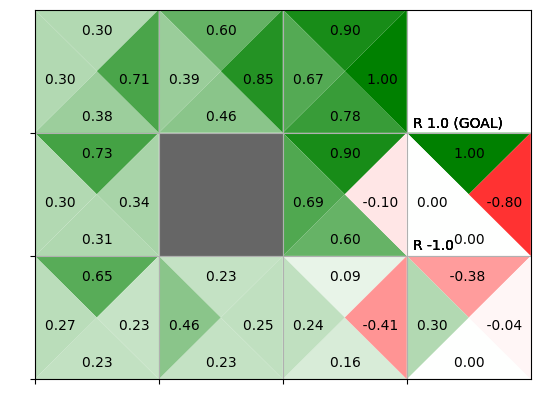

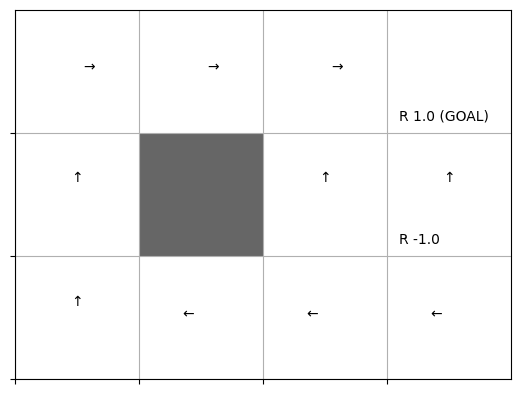

In [ ]:
env = GridWorld()
agent = SarsaAgent()

episodes = 10000

for episode in range(episodes):
    state = env.reset()
    agent.reset()

    # 1回のSt,At,Rt,St+1,At+1の取り出しごとに方策評価と方策改善を行う
    while True:
        # SARSAの取り出し
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        # 方策評価と方策改善
        agent.update(state, action, reward, done)   # doneは次の状態がゴールかどうか

        if done:
            # ゴールした時も呼ぶ
            agent.update(next_state, None, None, None)
            break
        # 状態遷移
        state = next_state

env.render_q(agent.Q)

爆弾があるマスから遠ざかるような行動が得られた。

### 方策オフのSARSA

ターゲット方策と挙動方策を異なるようにして学習する。(オフポリシー)

**オフポリシーの注意点**

- ターゲット方策と挙動方策は似たようなものがよい。(今回は挙動方策をε-greedy、ターゲット方策をgreedyとした)
- 重点サンプリングを使って重みρ による補正をする

In [ ]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]       # 行動は行動方策bから選ぶ
        # キーと要素のリストを取得
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            # 重点サンプリングで用いる重みrhoを求める
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]    # pi[state]の中に入っている辞書からkey=actionを取り出す

        # 重点サンプリングによるTDターゲット補正
        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        # ターゲット方策を改善(greedyに改善)
        self.pi[state] = greedy_probs(self.Q, state, 0)
        # 挙動方策を改善(ε-greedyに改善)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


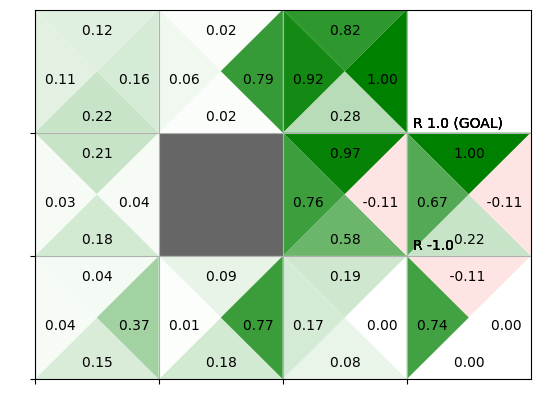

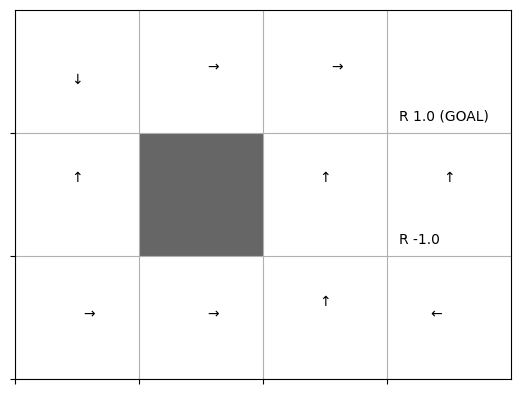

In [8]:
# 方策オフのSARSAの実行
env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000

for episode in range(episodes):
    state = env.reset()
    agent.reset()

    # 1回のSt,At,Rt,St+1,At+1の取り出しごとに方策評価と方策改善を行う
    while True:
        # SARSAの取り出し
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        # 方策評価と方策改善
        agent.update(state, action, reward, done)

        if done:
            # ゴールした時も呼ぶ
            agent.update(next_state, None, None, None)
            break
        # 状態遷移
        state = next_state

env.render_q(agent.Q)

### Q学習の実装

方策オフSARSAとQ学習の違い(ともにOffポリシー)

- 方策オフのSARSA → ターゲット方策をgreedyにする、データはSARSAを使用

- Q学習 → すべての方策を試す(ターゲット方策はこれまでの最適価値関数、挙動方策は今回サンプリングしたデータでの最適価値関数)、データはSARSを使用

In [9]:
from collections import defaultdict
import numpy as np
from common.gridworld import GridWorld
from common.utils import greedy_probs

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]       # 行動は行動方策bから選ぶ
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        # ターゲット方策を改善(greedyに改善)
        self.pi[state] = greedy_probs(self.Q, state, 0)
        # 挙動方策を更新
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


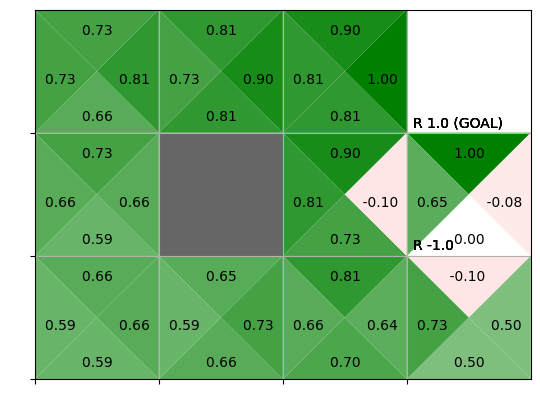

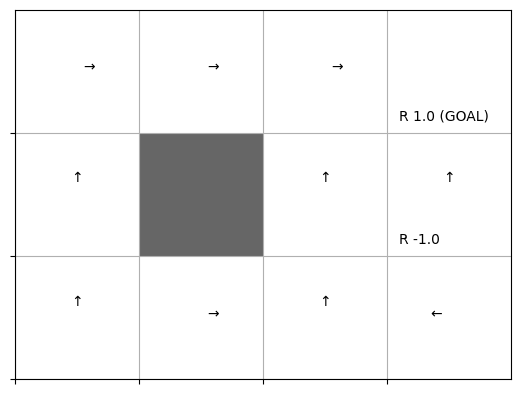

In [17]:
# Q学習の実行
env = GridWorld()
agent = QLearningAgent()

episodes = 10000

for episode in range(episodes):
    state = env.reset()

    # 1回のSt,At,Rt,St+1の取り出しごとに方策評価と方策改善を行う
    while True:
        # SARSAの取り出し
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        # 方策評価と方策改善
        agent.update(state, action, reward, next_state, done)

        if done:
            break
        # 状態遷移
        state = next_state

env.render_q(agent.Q)

### サンプルモデルvs分布モデル

- サンプルモデル...明確に確率分布を示さずに行動を決定する(サンプリングできる)エージェント
- 分布モデル...明確に確率分布を示すエージェント

In [16]:
# 方策を保持しないエージェントのQ学習

class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        ####### ※方策を持たない#########
        self.Q = defaultdict(lambda: 0)

    ####### ※方策を使わずにQ から直接行動を選択(ε-greedy)#########
    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            return np.argmax([self.Q[state, a] for a in range(self.action_size)])

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        ########　※方策を更新しない#########